<a href="https://colab.research.google.com/github/CamillaSemenzzatt/PROJETO-APLICADO-III/blob/main/Sistema_de_recomenda%C3%A7%C3%A3o_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.exceptions import UndefinedMetricWarning
import warnings
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import random
from collections import defaultdict

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# URLs dos arquivos CSV no GitHub
links_arquivos = {
    "tabela_ocupacao_trabalho_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_ocupacao_trabalho_atualizado.csv",
    "tabela_posicao_categoria_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_posicao_categoria_atualizado.csv",
    "tabela_genero_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_genero_atualizado.csv",
    "tabela_escolaridade_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_escolaridade_atualizado.csv",
    "tabela_posicao_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_posicao_atualizado.csv",
    "tabela_condicao_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_condicao_atualizado.csv",
    "tabela_idade_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_idade_atualizado.csv",
}

tabelas = {}

# Dicionário para mapear nomes de municípios/capitais para estados
depara_municipios = {
    'Acre': 'Acre',
    'Alagoas': 'Alagoas',
    'Amapá': 'Amapá',
    'Amazonas': 'Amazonas',
    'Aracaju (SE)': 'Sergipe',
    'Bahia': 'Bahia',
    'Belo Horizonte (MG)': 'Minas Gerais',
    'Belém (PA)': 'Pará',
    'Boa Vista (RR)': 'Roraima',
    'Brasília (DF)': 'Distrito Federal',
    'Campo Grande (MS)': 'Mato Grosso do Sul',
    'Ceará': 'Ceará',
    'Cuiabá (MT)': 'Mato Grosso',
    'Curitiba (PR)': 'Paraná',
    'Distrito Federal': 'Distrito Federal',
    'Espírito Santo': 'Espírito Santo',
    'Florianópolis (SC)': 'Santa Catarina',
    'Fonte: IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral': 'Fonte: IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral',
    'Fortaleza (CE)': 'Ceará',
    'Goiás': 'Goiás',
    'Goiânia (GO)': 'Goiás',
    'João Pessoa (PB)': 'Paraíba',
    'Macapá (AP)': 'Amapá',
    'Maceió (AL)': 'Alagoas',
    'Manaus (AM)': 'Amazonas',
    'Maranhão': 'Maranhão',
    'Mato Grosso': 'Mato Grosso',
    'Mato Grosso do Sul': 'Mato Grosso do Sul',
    'Minas Gerais': 'Minas Gerais',
    'Natal (RN)': 'Rio Grande do Norte',
    'Palmas (TO)': 'Tocantins',
    'Paraná': 'Paraná',
    'Paraíba': 'Paraíba',
    'Pará': 'Pará',
    'Pernambuco': 'Pernambuco',
    'Piauí': 'Piauí',
    'Porto Alegre (RS)': 'Rio Grande do Sul',
    'Porto Velho (RO)': 'Rondônia',
    'Recife (PE)': 'Pernambuco',
    'Rio Branco (AC)': 'Acre',
    'Rio Grande do Norte': 'Rio Grande do Norte',
    'Rio Grande do Sul': 'Rio Grande do Sul',
    'Rio de Janeiro': 'Rio de Janeiro',
    'Rio de Janeiro (RJ)': 'Rio de Janeiro',
    'Rondônia': 'Rondônia',
    'Roraima': 'Roraima',
    'Salvador (BA)': 'Bahia',
    'Santa Catarina': 'Santa Catarina',
    'Sergipe': 'Sergipe',
    'São Luís (MA)': 'Maranhão',
    'São Paulo': 'São Paulo',
    'Vitória (ES)': 'Espírito Santo',
    'São Paulo (SP)': 'São Paulo',
    'Teresina (PI)': 'Piauí'
}

# --- Leitura dos arquivos CSV e aplicação do depara ---
for nome_tabela, link in links_arquivos.items():
    try:
        # Tenta ler como CSV primeiro
        df = pd.read_csv(link)
        tabelas[nome_tabela] = df
    except pd.errors.ParserError:
        # Se der erro, tenta ler como tabela separada por tabulações
        df = pd.read_csv(link, sep='\t')
        tabelas[nome_tabela] = df

    # Aplica o depara_municipios se a coluna 'municipio' existir
    if 'municipio' in tabelas[nome_tabela].columns:
        tabelas[nome_tabela]['municipio'] = tabelas[nome_tabela]['municipio'].replace(depara_municipios)

In [ ]:
# --- Criação do banco de dados SQLite e população das tabelas ---
db_name = "projeto_aplicado.db"
conn = sqlite3.connect(db_name)

for nome_tabela, tabela in tabelas.items():
    # Use o nome da tabela do dicionário para criar a tabela no banco de dados
    tabela.to_sql(nome_tabela, conn, if_exists='replace', index=False)
    print(f"Tabela '{nome_tabela}' criada e dados inseridos no banco de dados.")

conn.close()
print("Banco de dados populado com sucesso!")

Tabela 'tabela_ocupacao_trabalho_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_categoria_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_genero_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_escolaridade_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_condicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_idade_atualizado' criada e dados inseridos no banco de dados.
Banco de dados populado com sucesso!


In [ ]:
# --- Verificação das tabelas e colunas no banco de dados (Opcional) ---
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tabelas_no_db = cursor.fetchall()

print("\nTabelas no banco de dados:")
for tabela in tabelas_no_db:
    nome_tabela_db = tabela[0]
    print(f"- {nome_tabela_db}")

    cursor.execute(f"PRAGMA table_info({nome_tabela_db});")
    colunas = cursor.fetchall()

    print(f"  Colunas da tabela {nome_tabela_db}:")
    for coluna in colunas:
        print(f"    - {coluna[1]}") # coluna[1] contém o nome da coluna
print("\n")

conn.close()


Tabelas no banco de dados:
- tabela_ocupacao_trabalho_atualizado
  Colunas da tabela tabela_ocupacao_trabalho_atualizado:
    - municipio
    - trimestre
    - Ocupação no trabalho
    - quantidade de ocupação no trabalho
- tabela_posicao_categoria_atualizado
  Colunas da tabela tabela_posicao_categoria_atualizado:
    - municipio
    - trimestre
    - Posição na ocupação
    - quantidade de posição e categoria
- tabela_genero_atualizado
  Colunas da tabela tabela_genero_atualizado:
    - municipio
    - trimestre
    - Sexo
    - quantidade de gênero
- tabela_escolaridade_atualizado
  Colunas da tabela tabela_escolaridade_atualizado:
    - municipio
    - trimestre
    - Nivel de Instrução
    - quantidade de escolaridade
- tabela_posicao_atualizado
  Colunas da tabela tabela_posicao_atualizado:
    - municipio
    - posição de ocupação
    - trimestre
    - quantidade de posição de ocupação
- tabela_condicao_atualizado
  Colunas da tabela tabela_condicao_atualizado:
    - municipio


In [ ]:
# --- Definição das consultas SQL ---
query_3_juncoes = """
SELECT
    o.municipio,
    o.trimestre,
    o.`Ocupação no trabalho`,
    o.`quantidade de ocupação no trabalho`,
    pc.`Posição na ocupação`,
    pc.`quantidade de posição e categoria`,
    g.Sexo,
    g.`quantidade de gênero`
FROM
    tabela_ocupacao_trabalho_atualizado o
LEFT JOIN
    tabela_posicao_categoria_atualizado pc ON o.municipio = pc.municipio AND o.trimestre = pc.trimestre
LEFT JOIN
    tabela_genero_atualizado g ON o.municipio = g.municipio AND o.trimestre = g.trimestre;
"""

query_4_juncoes = """
SELECT
    e.municipio,
    e.trimestre,
    e.`Nivel de Instrução` AS nivel_instrucao,
    e.`quantidade de escolaridade` AS quantidade_escolaridade,
    p.`posição de ocupação`,
    p.`quantidade de posição de ocupação`,
    c.`Condição de ocupação`,
    c.`quantidade de condição de ocupação`,
    i.Grupo AS grupo_etario,
    i.`quantidade de idade`
FROM
    tabela_escolaridade_atualizado e
LEFT JOIN
    tabela_posicao_atualizado p ON e.municipio = p.municipio AND e.trimestre = p.trimestre
LEFT JOIN
    tabela_condicao_atualizado c ON e.municipio = c.municipio AND e.trimestre = c.trimestre
LEFT JOIN
    tabela_idade_atualizado i ON e.municipio = i.municipio AND e.trimestre = i.trimestre;
"""

# --- Função para executar a consulta ---
def executar_consulta(query, db_name):
    conn = sqlite3.connect(db_name)
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# --- Execução das consultas e exibição dos resultados ---
print("Executando consulta com 3 junções...")
df_3_juncoes = executar_consulta(query_3_juncoes, db_name)
print("Resultado da consulta com 3 junções:")
display(df_3_juncoes)

print("\nExecutando consulta com 4 junções...")
df_4_juncoes = executar_consulta(query_4_juncoes, db_name)
print("Resultado da consulta com 4 junções:")
display(df_4_juncoes)

print("\nProcesso concluído.")

Executando consulta com 3 junções...
Resultado da consulta com 3 junções:


,municipio,trimestre,Ocupação no trabalho,quantidade de ocupação no trabalho,Posição na ocupação,quantidade de posição e categoria,Sexo,quantidade de gênero
0,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Homens,173.0
1,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Mulheres,168.0
2,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Homens,173.0
3,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Mulheres,168.0
4,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",205.0,Homens,173.0
...,...,...,...,...,...,...,...,...
438043,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - com carteira de trabal...,30.0,Mulheres,1377.0
438044,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Homens,1253.0
438045,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Mulheres,1377.0
438046,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador familiar auxiliar,7.0,Homens,1253.0



Executando consulta com 4 junções...
Resultado da consulta com 4 junções:


,municipio,trimestre,nivel_instrucao,quantidade_escolaridade,posição de ocupação,quantidade de posição de ocupação,Condição de ocupação,quantidade de condição de ocupação,grupo_etario,quantidade de idade
0,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,14 a 17 anos,38.0
1,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,18 a 24 anos,60.0
2,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,25 a 39 anos,123.0
3,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,40 a 59 anos,94.0
4,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,60 anos ou mais,26.0
...,...,...,...,...,...,...,...,...,...,...
898395,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,14 a 17 anos,190.0
898396,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,18 a 24 anos,328.0
898397,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,25 a 39 anos,805.0
898398,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,40 a 59 anos,872.0



Processo concluído.


In [ ]:
# --- Função para recomendar programas sociais com porcentagem e gráfico ---
def recomendar_programas_com_porcentagem(municipio, trimestre, df_3_juncoes, df_4_juncoes):
    """Recomenda programas sociais com base nas características do município e trimestre,
       usando duas tabelas separadas e exibe um gráfico das porcentagens."""

    dados_municipio_3 = df_3_juncoes[(df_3_juncoes["municipio"] == municipio) & (df_3_juncoes["trimestre"] == trimestre)].copy()
    dados_municipio_4 = df_4_juncoes[(df_4_juncoes["municipio"] == municipio) & (df_4_juncoes["trimestre"] == trimestre)].copy()

    if dados_municipio_3.empty and dados_municipio_4.empty:
        print(f"Nenhum dado disponível para o município: {municipio} no trimestre: {trimestre}")
        return

    print(f"\nAnálise para o município: {municipio} no trimestre: {trimestre}")

    total_pessoas = dados_municipio_4["quantidade de idade"].sum()

    if total_pessoas == 0:
        print("Não há registros suficientes para calcular porcentagens de beneficiários para programas sociais.")
        return

    recomendacoes = []
    porcentagens = {}

    # --- Recomendações e Cálculo de Porcentagens por Programa ---

    # Minha Casa Minha Vida
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_mcmv = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
        if beneficiarios_mcmv > 0:
            porcentagem_mcmv = (beneficiarios_mcmv / total_pessoas) * 100
            porcentagens["Minha Casa Minha Vida"] = porcentagem_mcmv

    # Auxílio Emergencial
    if "grupo_etario" in dados_municipio_4.columns and "Condição de ocupação" in dados_municipio_4.columns:
        condicao_idade = dados_municipio_4["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
        condicao_ocupacao = dados_municipio_4["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)
        beneficiarios_emergencial_df = dados_municipio_4.loc[condicao_idade & condicao_ocupacao]
        beneficiarios_emergencial = beneficiarios_emergencial_df["quantidade de idade"].sum()

        if beneficiarios_emergencial > 0:
            porcentagem_emergencial = (beneficiarios_emergencial / total_pessoas) * 100
            porcentagens["Auxílio Emergencial"] = porcentagem_emergencial

    # BPC (Benefício de Prestação Continuada)
    if "grupo_etario" in dados_municipio_4.columns or "Condição de ocupação" in dados_municipio_4.columns:
        beneficiarios_idosos = 0
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_idosos = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

        beneficiarios_deficiencia = 0
        if "Condição de ocupação" in dados_municipio_4.columns:
            if 'quantidade de condição de ocupação' in dados_municipio_4.columns:
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
            else:
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()

        total_beneficiarios_bpc = beneficiarios_idosos + beneficiarios_deficiencia

        if total_beneficiarios_bpc > 0:
            porcentagem_bpc = (total_beneficiarios_bpc / total_pessoas) * 100
            porcentagens["BPC"] = porcentagem_bpc

    # Programas para jovens (18 a 24 anos)
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_jovens = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
        if beneficiarios_jovens > 0:
            porcentagem_jovens = (beneficiarios_jovens / total_pessoas) * 100
            porcentagens["Programas para jovens"] = porcentagem_jovens

    # Brasil Alfabetizado
    if "nivel_instrucao" in dados_municipio_4.columns:
        beneficiarios_alfabetizacao = dados_municipio_4.loc[dados_municipio_4["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
        if beneficiarios_alfabetizacao > 0:
            porcentagem_alfabetizacao = (beneficiarios_alfabetizacao / total_pessoas) * 100
            porcentagens["Brasil Alfabetizado"] = porcentagem_alfabetizacao

    # Qualifica Mais
    if "Ocupação no trabalho" in dados_municipio_3.columns:
        condicao_qualifica = dados_municipio_3["Ocupação no trabalho"].str.contains("Trabalhadores de serviços, vendedores do comércio em lojas e mercados|Trabalhadores da produção de bens e serviços industriais", na=False, regex=True)
        beneficiarios_qualifica = dados_municipio_3.loc[condicao_qualifica, "quantidade de ocupação no trabalho"].sum()

        if beneficiarios_qualifica > 0:
             porcentagem_qualifica = (beneficiarios_qualifica / total_pessoas) * 100
             porcentagens["Qualifica Mais"] = porcentagem_qualifica

    # --- Exibição das Recomendações e Gráfico ---
    if not porcentagens:
        print("\nNenhum programa social recomendado com base nos dados disponíveis para este município e trimestre.")
    else:
        print("\nPotenciais Programas Sociais e Porcentagem de Beneficiários:")
        for programa, percentual in porcentagens.items():
             print(f"- {programa}: {percentual:.2f}% das pessoas se enquadram nos critérios.")

        if porcentagens:
            programas = list(porcentagens.keys())
            percentuais = list(porcentagens.values())

            plt.figure(figsize=(14, 7))
            plt.bar(programas, percentuais, color='#2E8B57')
            plt.ylabel("Porcentagem de Pessoas Potencialmente Beneficiadas (%)")
            plt.title(f"Porcentagem de Pessoas Potencialmente Beneficiadas por Programa Social\n em {municipio} no {trimestre}")
            plt.xticks(rotation=45, ha='right')
            plt.ylim(0, 100)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

In [ ]:
# --- Função para escolher município e trimestre com widgets ---
def escolher_municipio_e_trimestre():
    # Assumindo que df_3_juncoes e df_4_juncoes foram carregados globalmente
    if 'df_3_juncoes' not in globals() or 'df_4_juncoes' not in globals():
        print("DataFrames df_3_juncoes ou df_4_juncoes não encontrados. Execute a célula de carregamento de dados primeiro.")
        return

    municipios_disponiveis = sorted(df_3_juncoes["municipio"].unique())
    trimestres_disponiveis = sorted(df_3_juncoes["trimestre"].unique())

    # Adiciona um valor vazio no início das opções
    municipios_disponiveis = [''] + municipios_disponiveis
    trimestres_disponiveis = [''] + trimestres_disponiveis

    municipio_widget = widgets.Dropdown(
        options=municipios_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Município:',
        disabled=False,
    )

    trimestre_widget = widgets.Dropdown(
        options=trimestres_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Trimestre:',
        disabled=False,
    )

    output_widget = widgets.Output()

    def on_change(change):
        with output_widget:
            output_widget.clear_output()  # Limpa a saída anterior
            municipio_escolhido = municipio_widget.value
            trimestre_escolhido = trimestre_widget.value

            if municipio_escolhido and trimestre_escolhido:
                print(f"Analisando dados para o município: {municipio_escolhido} e trimestre: {trimestre_escolhido}")
                recomendar_programas_com_porcentagem(municipio_escolhido, trimestre_escolhido, df_3_juncoes, df_4_juncoes)
            elif municipio_escolhido or trimestre_escolhido:
                print("Por favor, selecione tanto um município quanto um trimestre.")
            else:
                print("Selecione um município e um trimestre para ver as recomendações.")

    municipio_widget.observe(on_change, names='value')
    trimestre_widget.observe(on_change, names='value')

    display(widgets.VBox([municipio_widget, trimestre_widget, output_widget]))

# Chame a função para exibir os widgets e iniciar o sistema de recomendação
escolher_municipio_e_trimestre()

In [ ]:
print("\n--- Treinamento de Modelo de Classificação (RandomForestClassifier) com Amostra Reduzida ---")

# 1. Definir a Tarefa, Features (X) e Target (y)
target_classificacao = 'Condição de ocupação'

features_classificacao = [
    'municipio',
    'trimestre',
    'nivel_instrucao',
    'posição de ocupação',
    'grupo_etario',
    'quantidade_escolaridade',
    'quantidade de posição de ocupação',
    'quantidade de idade',
    'quantidade de condição de ocupação'
]

colunas_necessarias_classificacao = features_classificacao + [target_classificacao]

if all(col in df_4_juncoes.columns for col in colunas_necessarias_classificacao):

    df_modelo_classificacao = df_4_juncoes[colunas_necessarias_classificacao].copy()
    df_modelo_classificacao.dropna(subset=[target_classificacao], inplace=True)

    if df_modelo_classificacao.empty:
        print("DataFrame vazio após remover valores ausentes no target. Não é possível treinar o modelo.")
    else:
        X = df_modelo_classificacao.drop(target_classificacao, axis=1)
        y = df_modelo_classificacao[target_classificacao]

        # --- ADICIONANDO AMOSTRAGEM AQUI ---
        fracao_amostra = 0.1 # Ajuste este valor conforme necessário

        print(f"\nUsando uma amostra de {fracao_amostra*100:.0f}% dos dados para testes rápidos.")

        try:
             X_amostra, _, y_amostra, _ = train_test_split(X, y, train_size=fracao_amostra, random_state=42, stratify=y)
             print("Amostragem estratificada realizada com sucesso.")
        except ValueError as e:
             print(f"Erro ao realizar amostragem estratificada na amostra inicial: {e}. Tentando amostragem aleatória simples...")
             df_amostra = df_modelo_classificacao.sample(frac=fracao_amostra, random_state=42).copy()
             X_amostra = df_amostra.drop(target_classificacao, axis=1)
             y_amostra = df_amostra[target_classificacao]

        print(f"Tamanho da amostra total: {len(X_amostra)} amostras")
        # --- FIM DA ADIÇÃO DA AMOSTRAGEM ---

        colunas_categoricas = X_amostra.select_dtypes(include=['object', 'category']).columns.tolist()
        colunas_numericas = X_amostra.select_dtypes(include=np.number).columns.tolist()

        # 2. Pré-processar Dados usando Pipelines e ColumnTransformer - Usando a amostra
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', 'passthrough', colunas_numericas),
                ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
            ],
            remainder='passthrough'
        )

        # 3. Dividir a Amostra em Treino e Teste
        try:
            X_treino, X_teste, y_treino, y_teste = train_test_split(X_amostra, y_amostra, test_size=0.20, random_state=42, stratify=y_amostra)
        except ValueError as e:
            print(f"Erro ao dividir a amostra de treino/teste com stratify: {e}")
            print("Isso pode ocorrer se alguma classe na amostra tiver apenas uma amostra.")
            print("Tentando dividir a amostra sem stratify...")
            X_treino, X_teste, y_treino, y_teste = train_test_split(X_amostra, y_amostra, test_size=0.20, random_state=42)

        print(f"Tamanho do conjunto de treino (amostra): {len(X_treino)} amostras")
        print(f"Tamanho do conjunto de teste (amostra): {len(X_teste)} amostras")

        # 4. Definir Pipeline para RandomForestClassifier com SMOTE
        pipeline_rf = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42))
        ])

        # 5. Treinar o Modelo (Diretamente o Pipeline)
        print("\nTreinando o Pipeline (RandomForestClassifier com SMOTE) diretamente...")
        try:
            pipeline_rf.fit(X_treino, y_treino)
            print("Fit do Pipeline concluído.")

            # --- Gerar Previsões no conjunto de teste ---
            y_pred_rf = pipeline_rf.predict(X_teste)
            print("\nPrevisões geradas para o conjunto de teste.")

            # --- Avaliar o Modelo ---
            print("\nMétricas de Avaliação no Conjunto de Teste:")

            # Acurácia
            accuracy = accuracy_score(y_teste, y_pred_rf)
            print(f"  Acurácia: {accuracy:.2f}")

            # Precisão, Revocação e F1-Score
            try:
                precision = precision_score(y_teste, y_pred_rf, average='weighted')
                recall = recall_score(y_teste, y_pred_rf, average='weighted')
                f1 = f1_score(y_teste, y_pred_rf, average='weighted')

                print(f"  Precisão (Weighted): {precision:.2f}")
                print(f"  Revocação (Weighted): {recall:.2f}")
                print(f"  F1-Score (Weighted): {f1:.2f}")

                # Relatório de Classificação completo
                print("\nRelatório de Classificação:")
                print(classification_report(y_teste, y_pred_rf))

            except ValueError as e:
                 print(f"Erro ao calcular métricas de Precisão, Revocação ou F1-Score: {e}")
                 print("Isso pode ocorrer se as previsões não contiverem todas as classes presentes nos valores reais de teste.")

            # AUC-ROC
            if hasattr(pipeline_rf, 'predict_proba'):
                try:
                    y_prob_rf = pipeline_rf.predict_proba(X_teste)
                    classes_na_amostra_total = np.unique(y_amostra)
                    y_teste_bin = label_binarize(y_teste, classes=classes_na_amostra_total)
                    n_classes = y_teste_bin.shape[1]

                    if n_classes > 1:
                         auc_roc = roc_auc_score(y_teste_bin, y_prob_rf, average='weighted')
                         print(f"  AUC-ROC (Weighted OvR): {auc_roc:.2f}")
                    else:
                         print("  AUC-ROC não calculado: Apenas uma classe presente nos dados de teste.")
                except Exception as e:
                     print(f"Erro ao calcular AUC-ROC: {e}")
                     print("Verifique se y_prob_rf foi gerado corretamente e se há mais de uma classe no conjunto de teste.")
            else:
                print("\nModelo não suporta predict_proba, AUC-ROC não calculado.")

        except Exception as e:
            print(f"\nErro durante o treinamento do Pipeline: {e}")
            print("O Pipeline não completou o treinamento.")

else:
    print("Algumas colunas necessárias para o modelo de classificação não foram encontradas em df_4_juncoes.")


--- Treinamento de Modelo de Classificação (RandomForestClassifier) com Amostra Reduzida ---

Usando uma amostra de 10% dos dados para testes rápidos.
Amostragem estratificada realizada com sucesso.
Tamanho da amostra total: 89840 amostras
Tamanho do conjunto de treino (amostra): 71872 amostras
Tamanho do conjunto de teste (amostra): 17968 amostras

Treinando o Pipeline (RandomForestClassifier com SMOTE) diretamente...
Fit do Pipeline concluído.

Previsões geradas para o conjunto de teste.

Métricas de Avaliação no Conjunto de Teste:
  Acurácia: 0.82
  Precisão (Weighted): 0.82
  Revocação (Weighted): 0.82
  F1-Score (Weighted): 0.82

Relatório de Classificação:
                                precision    recall  f1-score   support

     Fora da força de trabalho       0.86      0.87      0.87      4489
             Força de trabalho       0.76      0.77      0.76      4493
Força de trabalho - desocupada       0.88      0.88      0.88      4493
   Força de trabalho - ocupada       0.

In [ ]:
# --- Funções para Baseline de Popularidade ---

def get_all_possible_programs():
    """Retorna uma lista de todos os programas sociais potenciais que a função de recomendação considera."""
    return [
        "Minha Casa Minha Vida",
        "Auxílio Emergencial",
        "BPC",
        "Programas para jovens",
        "Brasil Alfabetizado",
        "Qualifica Mais"
    ]

def calculate_program_popularity(df_3_juncoes, df_4_juncoes):
    """Calcula a porcentagem média de potenciais beneficiários para cada programa em todos os dados."""
    program_total_beneficiaries = defaultdict(float)
    program_total_population = defaultdict(float)
    program_count = defaultdict(int)

    combinacoes_unicas_3 = df_3_juncoes[['municipio', 'trimestre']].drop_duplicates()
    combinacoes_unicas_4 = df_4_juncoes[['municipio', 'trimestre']].drop_duplicates()

    todas_combinacoes = pd.concat([combinacoes_unicas_3, combinacoes_unicas_4]).drop_duplicates().values.tolist()

    for municipio, trimestre in todas_combinacoes:
        dados_municipio_3 = df_3_juncoes[(df_3_juncoes["municipio"] == municipio) & (df_3_juncoes["trimestre"] == trimestre)].copy()
        dados_municipio_4 = df_4_juncoes[(df_4_juncoes["municipio"] == municipio) & (df_4_juncoes["trimestre"] == trimestre)].copy()

        if dados_municipio_3.empty and dados_municipio_4.empty:
            continue

        total_pessoas = dados_municipio_4["quantidade de idade"].sum()

        if total_pessoas == 0:
            continue

        # Minha Casa Minha Vida
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_mcmv = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
            if beneficiarios_mcmv > 0:
                 program_total_beneficiaries["Minha Casa Minha Vida"] += beneficiarios_mcmv
                 program_total_population["Minha Casa Minha Vida"] += total_pessoas
                 program_count["Minha Casa Minha Vida"] += 1

        # Auxílio Emergencial
        if "grupo_etario" in dados_municipio_4.columns and "Condição de ocupação" in dados_municipio_4.columns:
            condicao_idade = dados_municipio_4["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
            condicao_ocupacao = dados_municipio_4["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)
            beneficiarios_emergencial_df = dados_municipio_4.loc[condicao_idade & condicao_ocupacao]
            beneficiarios_emergencial = beneficiarios_emergencial_df["quantidade de idade"].sum()

            if beneficiarios_emergencial > 0:
                program_total_beneficiaries["Auxílio Emergencial"] += beneficiarios_emergencial
                program_total_population["Auxílio Emergencial"] += total_pessoas
                program_count["Auxílio Emergencial"] += 1

        # BPC (Benefício de Prestação Continuada)
        if "grupo_etario" in dados_municipio_4.columns or "Condição de ocupação" in dados_municipio_4.columns:
            beneficiarios_idosos = 0
            if "grupo_etario" in dados_municipio_4.columns:
                beneficiarios_idosos = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

            beneficiarios_deficiencia = 0
            if "Condição de ocupação" in dados_municipio_4.columns:
                 if 'quantidade de condição de ocupação' in dados_municipio_4.columns:
                      beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
                 else:
                      beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()

            total_beneficiarios_bpc = beneficiarios_idosos + beneficiarios_deficiencia

            if total_beneficiarios_bpc > 0:
                program_total_beneficiaries["BPC"] += total_beneficiarios_bpc
                program_total_population["BPC"] += total_pessoas
                program_count["BPC"] += 1

        # Programas para jovens (18 a 24 anos)
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_jovens = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
            if beneficiarios_jovens > 0:
                program_total_beneficiaries["Programas para jovens"] += beneficiarios_jovens
                program_total_population["Programas para jovens"] += total_pessoas
                program_count["Programas para jovens"] += 1

        # Brasil Alfabetizado
        if "nivel_instrucao" in dados_municipio_4.columns:
            beneficiarios_alfabetizacao = dados_municipio_4.loc[dados_municipio_4["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
            if beneficiarios_alfabetizacao > 0:
                program_total_beneficiaries["Brasil Alfabetizado"] += beneficiarios_alfabetizacao
                program_total_population["Brasil Alfabetizado"] += total_pessoas
                program_count["Brasil Alfabetizado"] += 1

        # Qualifica Mais
        if "Ocupação no trabalho" in dados_municipio_3.columns:
            condicao_qualifica = dados_municipio_3["Ocupação no trabalho"].str.contains("Trabalhadores de serviços, vendedores do comércio em lojas e mercados|Trabalhadores da produção de bens e serviços industriais", na=False, regex=True)
            beneficiarios_qualifica = dados_municipio_3.loc[condicao_qualifica, "quantidade de ocupação no trabalho"].sum()

            if beneficiarios_qualifica > 0:
                 program_total_beneficiaries["Qualifica Mais"] += beneficiarios_qualifica
                 program_total_population["Qualifica Mais"] += total_pessoas
                 program_count["Qualifica Mais"] += 1

    popularity_scores = {}
    for program in get_all_possible_programs():
        if program_total_population[program] > 0:
            popularity_scores[program] = (program_total_beneficiaries[program] / program_total_population[program]) * 100
        else:
            popularity_scores[program] = 0

    return popularity_scores

def recommend_by_popularity(df_3_juncoes, df_4_juncoes):
    """Recomenda programas sociais com base na popularidade geral."""
    popularity_scores = calculate_program_popularity(df_3_juncoes, df_4_juncoes)

    print("\n--- Recomendação Baseada em Popularidade (Baseline) ---")
    if not popularity_scores:
        print("Não foi possível calcular a popularidade dos programas com os dados disponíveis.")
        return

    sorted_popularity = sorted(popularity_scores.items(), key=lambda item: item[1], reverse=True)

    print("\nProgramas Sociais Recomendados por Popularidade (Potenciais Beneficiários Médios):")
    for program, score in sorted_popularity:
        print(f"- {program}: {score:.2f}% (Média geral)")

# Execute o baseline de popularidade após carregar os dados
if 'df_3_juncoes' in globals() and 'df_4_juncoes' in globals():
    recommend_by_popularity(df_3_juncoes, df_4_juncoes)
else:
    print("\nDataFrames df_3_juncoes ou df_4_juncoes não encontrados. Carregue os dados primeiro para executar o baseline.")


--- Recomendação Baseada em Popularidade (Baseline) ---

Programas Sociais Recomendados por Popularidade (Potenciais Beneficiários Médios):
- Minha Casa Minha Vida: 30.97% (Média geral)
- Auxílio Emergencial: 18.96% (Média geral)
- BPC: 17.23% (Média geral)
- Programas para jovens: 13.88% (Média geral)
- Brasil Alfabetizado: 12.36% (Média geral)
- Qualifica Mais: 0.00% (Média geral)



--- Top 3 Programas Sociais por Popularidade (Baseline) ---


<ipython-input-21-327db32f6745>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentuais, y=programas, palette='Greens_d')


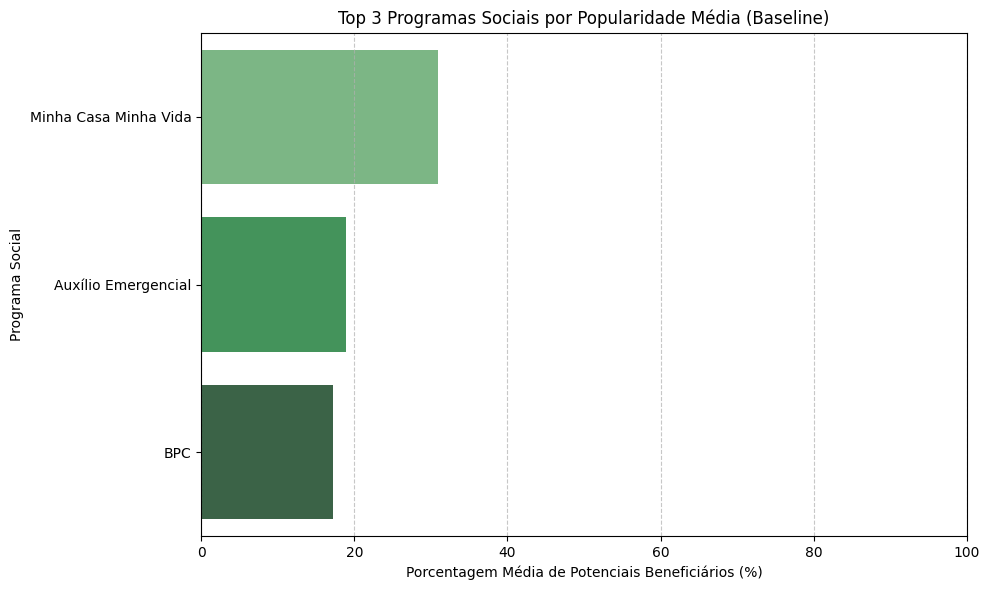

Gráfico dos Top 3 programas sociais por popularidade gerado.

Processo de geração do gráfico do Top 3 programas concluído.


In [ ]:
# --- Etapa 13: Top 3 Programas Sociais por Popularidade (Baseline) ---
print("\n--- Top 3 Programas Sociais por Popularidade (Baseline) ---")

if 'df_3_juncoes' in globals() and 'df_4_juncoes' in globals():
    try:
        # Calcula a popularidade de todos os programas
        popularity_scores = calculate_program_popularity(df_3_juncoes, df_4_juncoes)

        if popularity_scores:
            # Ordena os programas por popularidade em ordem decrescente e pega o top 3
            sorted_popularity = sorted(popularity_scores.items(), key=lambda item: item[1], reverse=True)
            top_3_programas = sorted_popularity[:3]

            if top_3_programas:
                programas = [item[0] for item in top_3_programas]
                percentuais = [item[1] for item in top_3_programas]

                plt.figure(figsize=(10, 6))
                sns.barplot(x=percentuais, y=programas, palette='Greens_d')
                plt.xlabel("Porcentagem Média de Potenciais Beneficiários (%)")
                plt.ylabel("Programa Social")
                plt.title("Top 3 Programas Sociais por Popularidade Média (Baseline)")
                plt.xlim(0, 100) # Limita o eixo X a 100%
                plt.grid(axis='x', linestyle='--', alpha=0.7)
                plt.tight_layout()
                plt.show()
                print("Gráfico dos Top 3 programas sociais por popularidade gerado.")
            else:
                print("Não foi possível identificar os Top 3 programas com base na popularidade calculada.")

        else:
            print("Não foi possível calcular a popularidade dos programas para identificar o Top 3.")
    except Exception as e:
        print(f"Não foi possível gerar o gráfico do Top 3 programas. Erro: {e}")
else:
    print("\nDataFrames df_3_juncoes ou df_4_juncoes não encontrados. Não é possível gerar o gráfico do Top 3 programas.")

print("\nProcesso de geração do gráfico do Top 3 programas concluído.")


--- Gerando Mapas de Calor por Programa Social, Município e Ano ---

Calculando porcentagens de potenciais beneficiários por município e ano para mapas de calor...

Calculo de porcentagens anuais concluído. Gerando mapas de calor por ano...


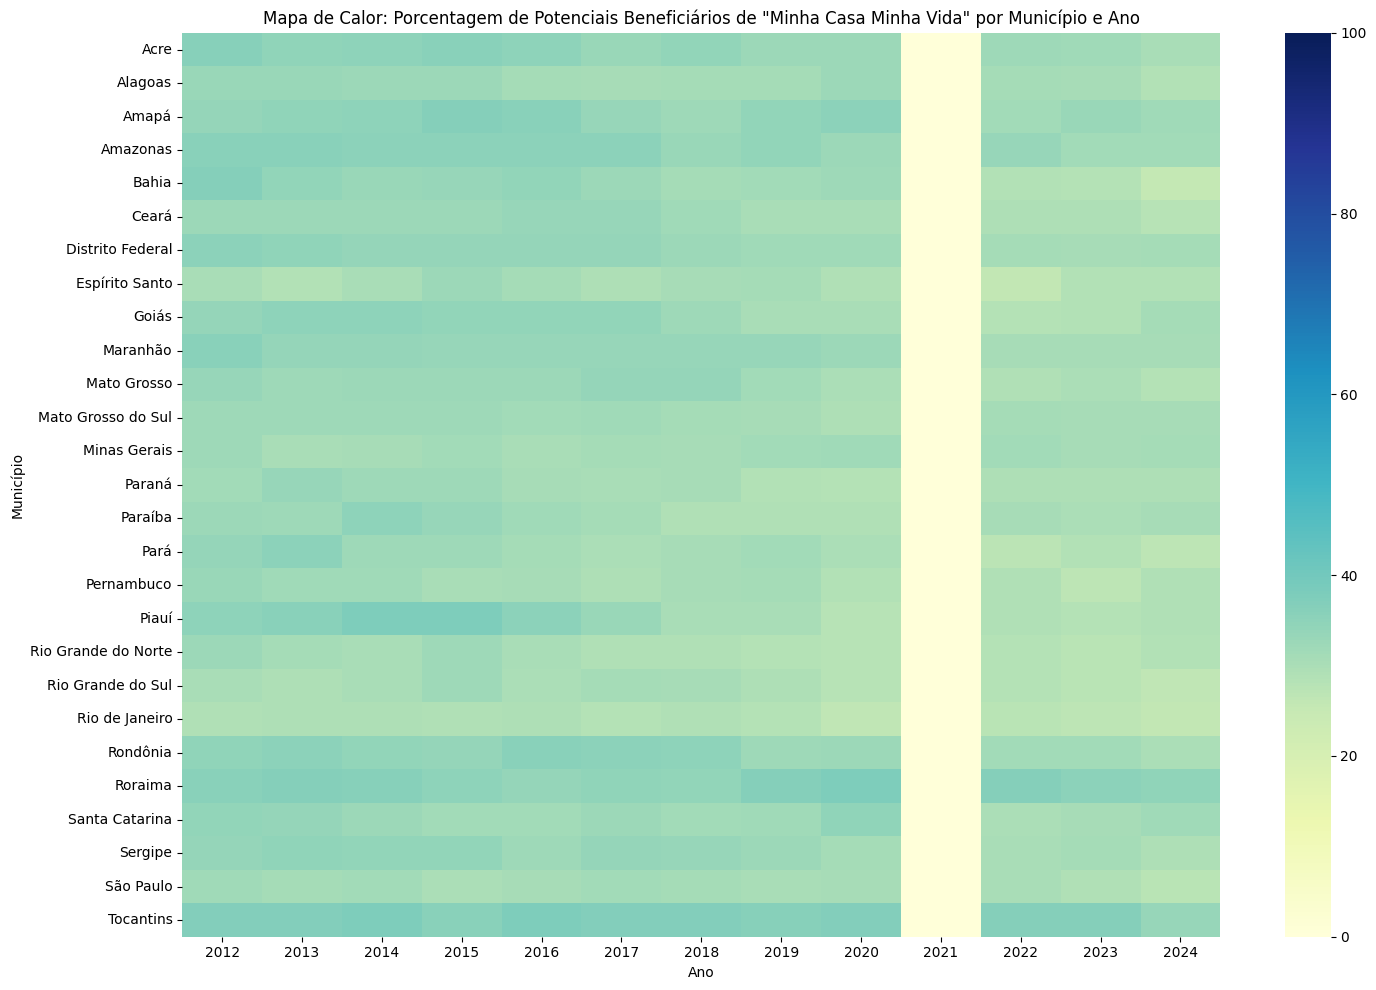

Mapa de calor para 'Minha Casa Minha Vida' por ano gerado.


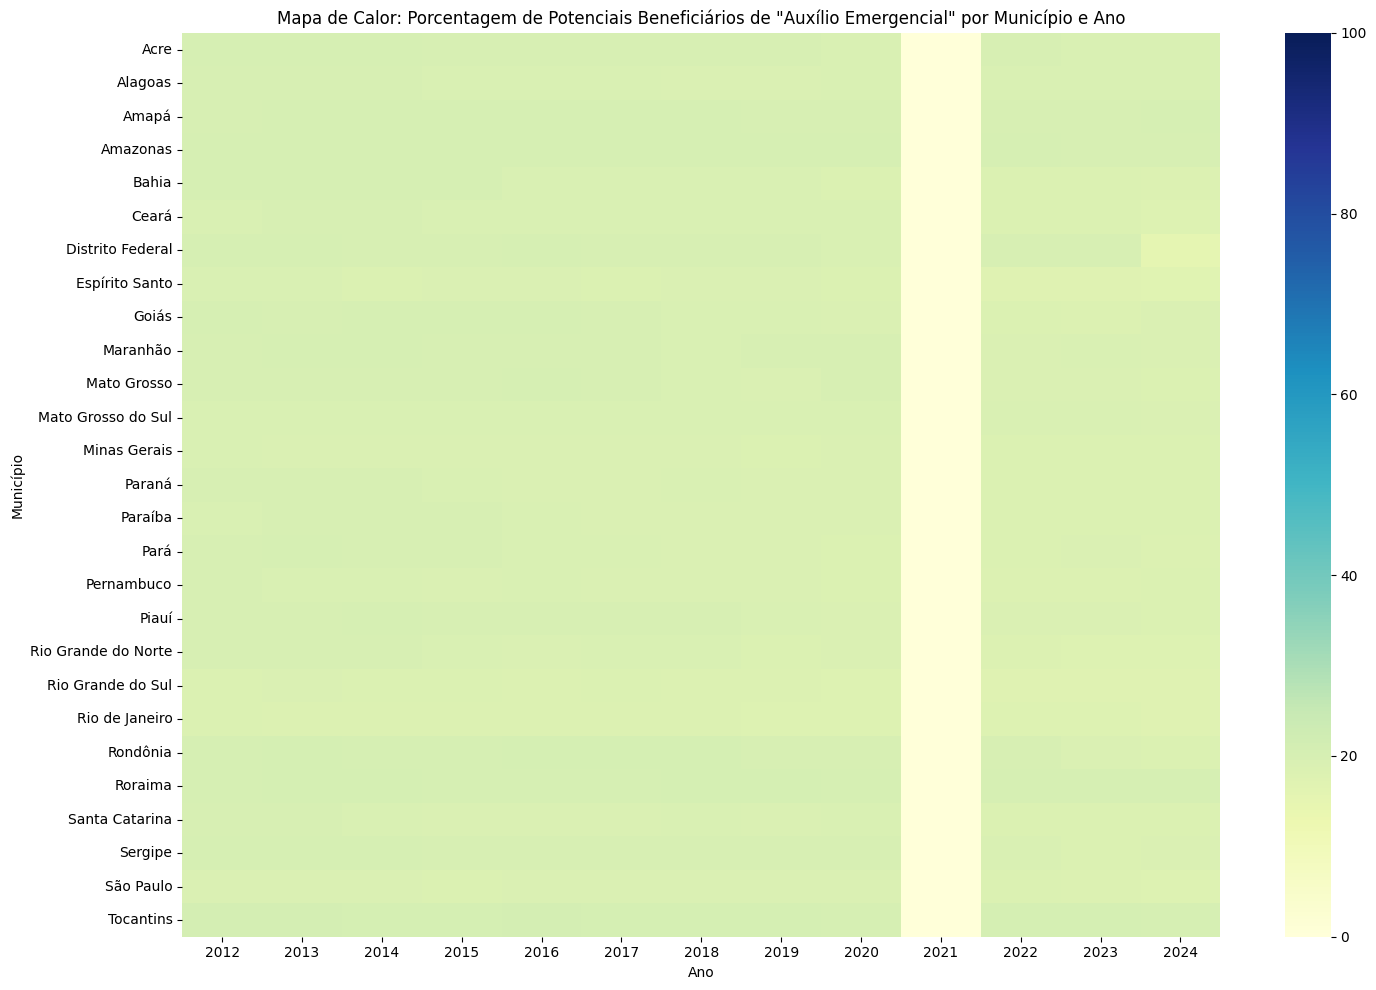

Mapa de calor para 'Auxílio Emergencial' por ano gerado.


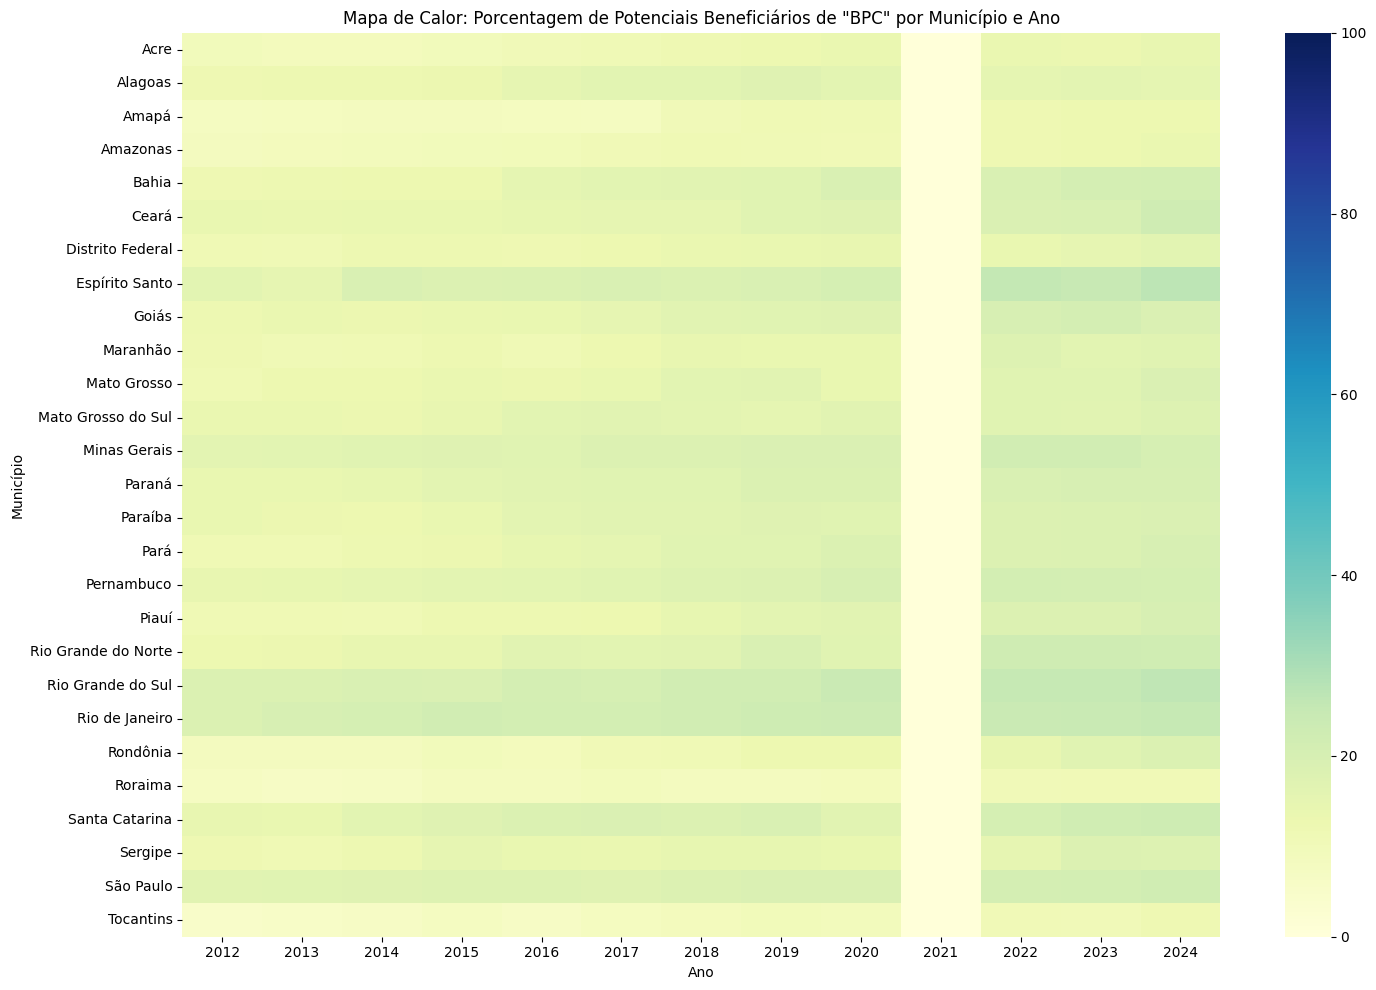

Mapa de calor para 'BPC' por ano gerado.


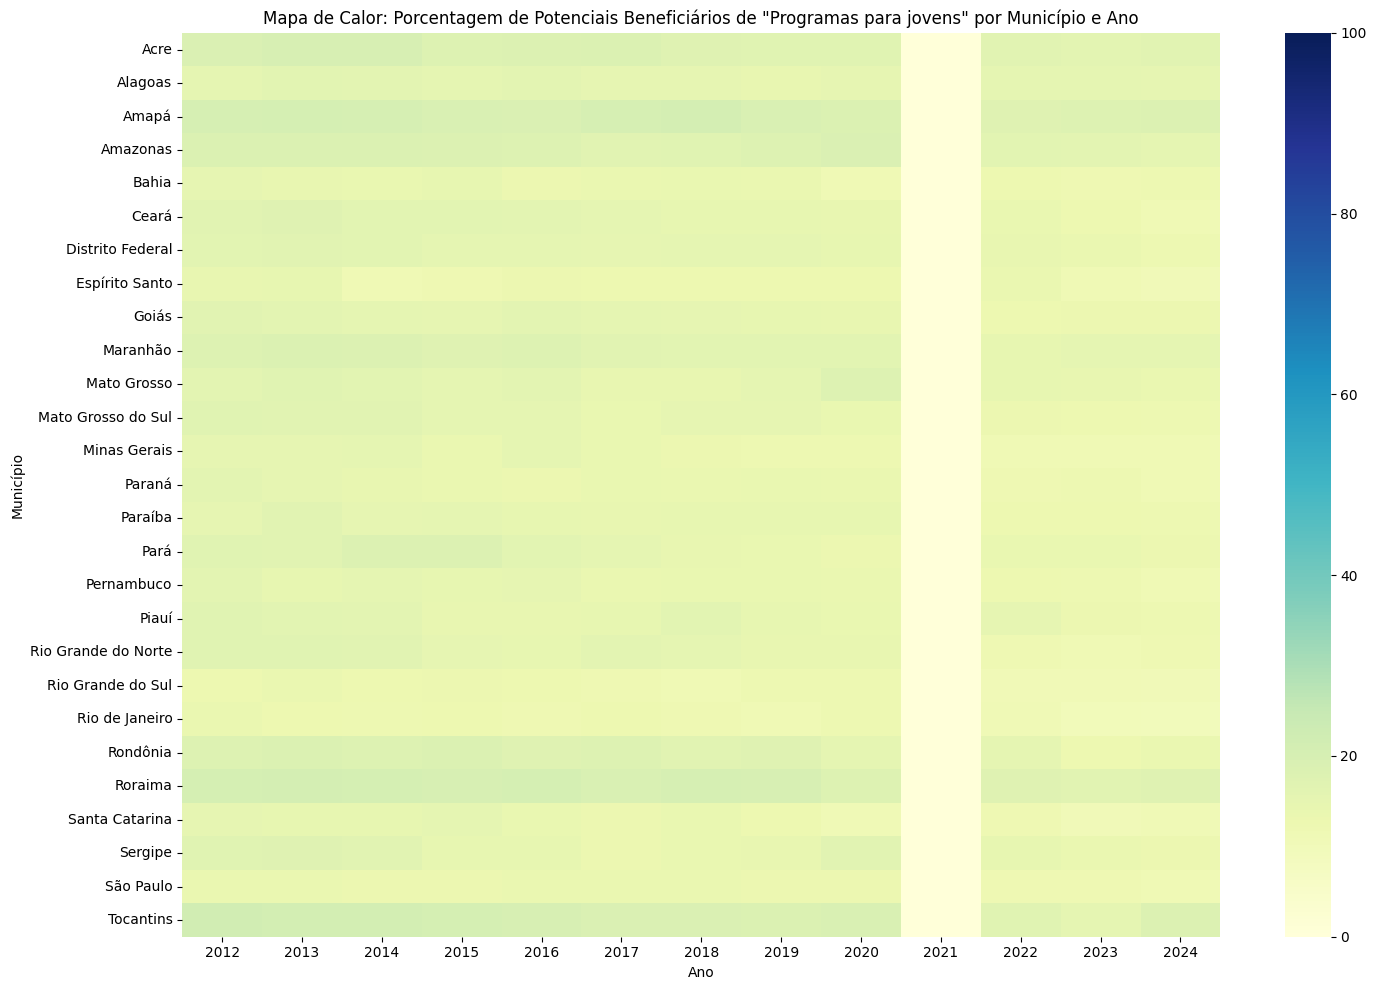

Mapa de calor para 'Programas para jovens' por ano gerado.


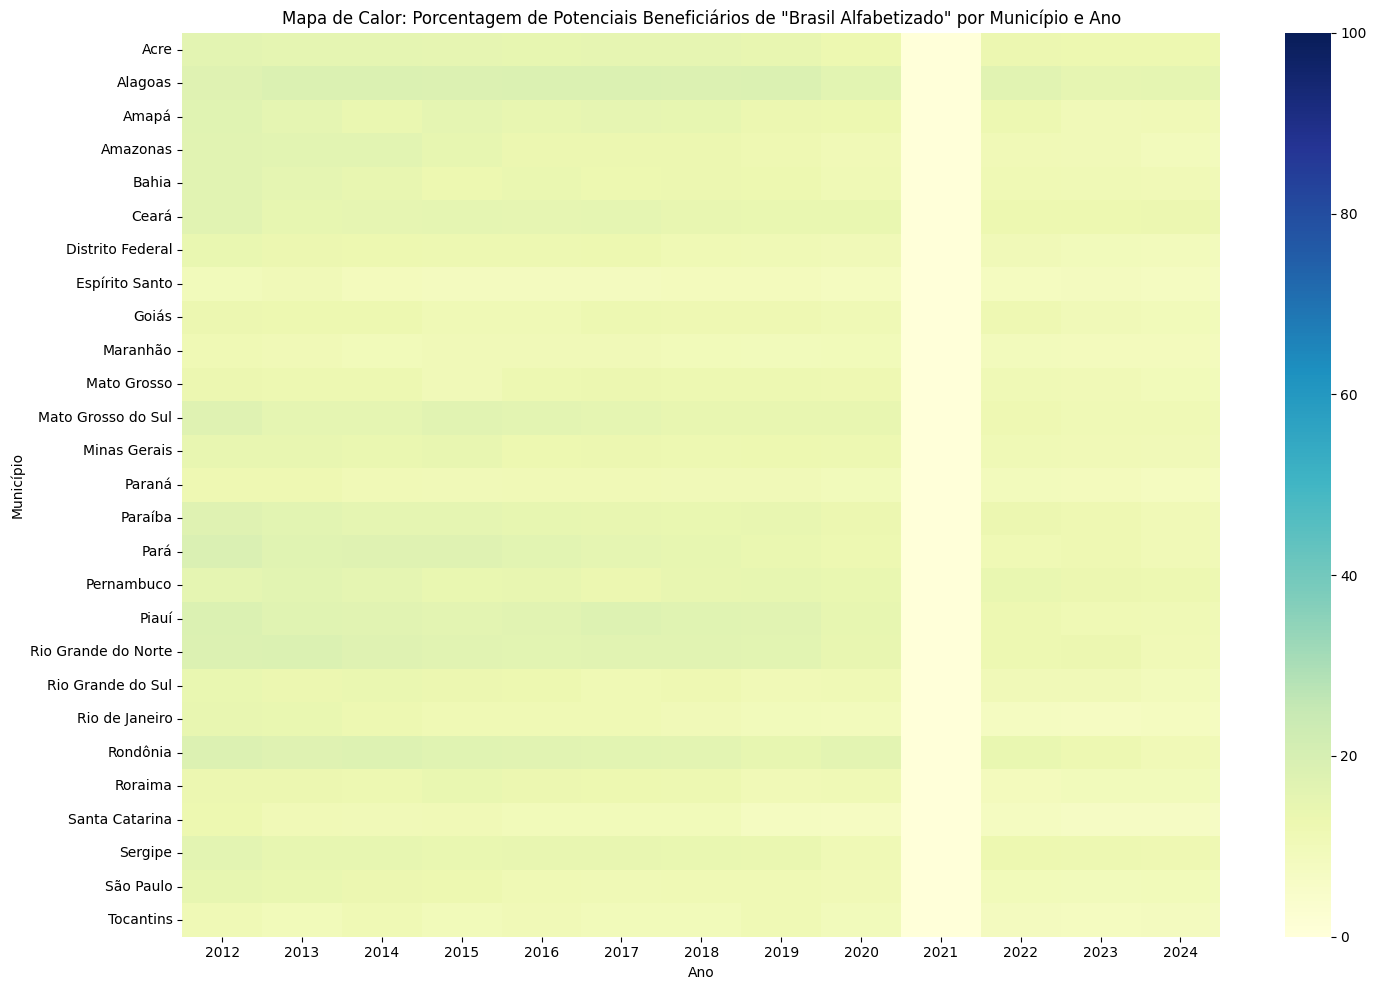

Mapa de calor para 'Brasil Alfabetizado' por ano gerado.
Não há dados suficientes ou porcentagem de beneficiários para o programa 'Qualifica Mais' para gerar um mapa de calor por ano.

Processo de geração de mapas de calor por programa social e ano concluído.


In [ ]:
# --- Etapa 15 (Modificada): Mapa de Calor por Programa Social, Município e Ano ---
print("\n--- Gerando Mapas de Calor por Programa Social, Município e Ano ---")

# Lista de todos os programas sociais considerados
todos_programas = get_all_possible_programs() # Usamos a função definida no baseline

if 'df_3_juncoes' in globals() and 'df_4_juncoes' in globals():
    # Cria cópias dos DataFrames para adicionar a coluna 'ano' sem modificar os originais
    df_3_anual = df_3_juncoes.copy()
    df_4_anual = df_4_juncoes.copy()

    # Extrai o ano da coluna 'trimestre' em ambos os DataFrames
    df_3_anual['ano'] = df_3_anual['trimestre'].str.extract(r'(\d{4})')
    df_4_anual['ano'] = df_4_anual['trimestre'].str.extract(r'(\d{4})')

    # Converte a coluna 'ano' para numérico e remove linhas com valores ausentes
    df_3_anual['ano'] = pd.to_numeric(df_3_anual['ano'], errors='coerce')
    df_4_anual['ano'] = pd.to_numeric(df_4_anual['ano'], errors='coerce')
    df_3_anual.dropna(subset=['ano'], inplace=True)
    df_4_anual.dropna(subset=['ano'], inplace=True)


    # Prepara um DataFrame para armazenar as porcentagens de cada programa por município e ano
    combinacoes_unicas_3_anual = df_3_anual[['municipio', 'ano']].drop_duplicates()
    combinacoes_unicas_4_anual = df_4_anual[['municipio', 'ano']].drop_duplicates()
    todas_combinacoes_df_anual = pd.concat([combinacoes_unicas_3_anual, combinacoes_unicas_4_anual]).drop_duplicates().reset_index(drop=True)

    # Inicializa colunas para as porcentagens de cada programa com 0
    for programa in todos_programas:
        todas_combinacoes_df_anual[programa] = 0.0

    print("\nCalculando porcentagens de potenciais beneficiários por município e ano para mapas de calor...")

    # Itera sobre cada combinação única de município e ano
    for index, row in todas_combinacoes_df_anual.iterrows():
        municipio = row['municipio']
        ano = row['ano']

        # Filtra os dados anuais para o município e ano específicos
        dados_municipio_3_anual = df_3_anual[(df_3_anual["municipio"] == municipio) & (df_3_anual["ano"] == ano)].copy()
        dados_municipio_4_anual = df_4_anual[(df_4_anual["municipio"] == municipio) & (df_4_anual["ano"] == ano)].copy()

        if dados_municipio_4_anual.empty or dados_municipio_4_anual["quantidade de idade"].sum() == 0:
            continue # Pula se não houver dados populacionais para o cálculo naquele ano/município

        total_pessoas_anual = dados_municipio_4_anual["quantidade de idade"].sum()

        # Calcula as porcentagens para cada programa para o ano/município
        porcentagens_anual = {}

        # Minha Casa Minha Vida
        if "grupo_etario" in dados_municipio_4_anual.columns:
            beneficiarios_mcmv_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
            if beneficiarios_mcmv_anual > 0:
                porcentagens_anual["Minha Casa Minha Vida"] = (beneficiarios_mcmv_anual / total_pessoas_anual) * 100

        # Auxílio Emergencial
        if "grupo_etario" in dados_municipio_4_anual.columns and "Condição de ocupação" in dados_municipio_4_anual.columns:
            condicao_idade_anual = dados_municipio_4_anual["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
            condicao_ocupacao_anual = dados_municipio_4_anual["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)
            beneficiarios_emergencial_anual_df = dados_municipio_4_anual.loc[condicao_idade_anual & condicao_ocupacao_anual]
            beneficiarios_emergencial_anual = beneficiarios_emergencial_anual_df["quantidade de idade"].sum()

            if beneficiarios_emergencial_anual > 0:
                porcentagens_anual["Auxílio Emergencial"] = (beneficiarios_emergencial_anual / total_pessoas_anual) * 100

        # BPC (Benefício de Prestação Continuada)
        if "grupo_etario" in dados_municipio_4_anual.columns or "Condição de ocupação" in dados_municipio_4_anual.columns:
            beneficiarios_idosos_anual = 0
            if "grupo_etario" in dados_municipio_4_anual.columns:
                beneficiarios_idosos_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

            beneficiarios_deficiencia_anual = 0
            if "Condição de ocupação" in dados_municipio_4_anual.columns:
                 if 'quantidade de condição de ocupação' in dados_municipio_4_anual.columns:
                      beneficiarios_deficiencia_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
                 else:
                      beneficiarios_deficiencia_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()

            total_beneficiarios_bpc_anual = beneficiarios_idosos_anual + beneficiarios_deficiencia_anual

            if total_beneficiarios_bpc_anual > 0:
                porcentagens_anual["BPC"] = (total_beneficiarios_bpc_anual / total_pessoas_anual) * 100

        # Programas para jovens (18 a 24 anos)
        if "grupo_etario" in dados_municipio_4_anual.columns:
            beneficiarios_jovens_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
            if beneficiarios_jovens_anual > 0:
                porcentagens_anual["Programas para jovens"] = (beneficiarios_jovens_anual / total_pessoas_anual) * 100

        # Brasil Alfabetizado
        if "nivel_instrucao" in dados_municipio_4_anual.columns:
            beneficiarios_alfabetizacao_anual = dados_municipio_4_anual.loc[dados_municipio_4_anual["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
            if beneficiarios_alfabetizacao_anual > 0:
                porcentagens_anual["Brasil Alfabetizado"] = (beneficiarios_alfabetizacao_anual / total_pessoas_anual) * 100

        # Qualifica Mais
        if "Ocupação no trabalho" in dados_municipio_3_anual.columns:
            condicao_qualifica_anual = dados_municipio_3_anual["Ocupação no trabalho"].str.contains("Trabalhadores de serviços, vendedores do comércio em lojas e mercados|Trabalhadores da produção de bens e serviços industriais", na=False, regex=True)
            beneficiarios_qualifica_anual = dados_municipio_3_anual.loc[condicao_qualifica_anual, "quantidade de ocupação no trabalho"].sum()

            if beneficiarios_qualifica_anual > 0:
                 porcentagens_anual["Qualifica Mais"] = (beneficiarios_qualifica_anual / total_pessoas_anual) * 100

        # Preenche o DataFrame de combinações anuais com as porcentagens calculadas
        for programa, percentual in porcentagens_anual.items():
            todas_combinacoes_df_anual.loc[(todas_combinacoes_df_anual['municipio'] == municipio) & (todas_combinacoes_df_anual['ano'] == ano), programa] = percentual

    print("\nCalculo de porcentagens anuais concluído. Gerando mapas de calor por ano...")

    # Gera um mapa de calor para cada programa social por ano
    for programa in todos_programas:
        if programa in todas_combinacoes_df_anual.columns and todas_combinacoes_df_anual[programa].sum() > 0: # Gera mapa apenas se houver dados para o programa
            try:
                # Reorganiza o DataFrame para o mapa de calor anual
                heatmap_data_programa_anual = todas_combinacoes_df_anual.pivot(index='municipio', columns='ano', values=programa).fillna(0)

                # Ordenar anos nas colunas
                anos_ordenados = sorted(heatmap_data_programa_anual.columns)
                heatmap_data_programa_anual = heatmap_data_programa_anual[anos_ordenados]

                plt.figure(figsize=(15, 10)) # Ajuste o tamanho conforme necessário
                sns.heatmap(heatmap_data_programa_anual, annot=False, cmap='YlGnBu', vmin=0, vmax=100) # vmin/vmax para escala consistente
                plt.title(f'Mapa de Calor: Porcentagem de Potenciais Beneficiários de "{programa}" por Município e Ano')
                plt.xlabel('Ano')
                plt.ylabel('Município')
                plt.tight_layout()
                plt.show()
                print(f"Mapa de calor para '{programa}' por ano gerado.")

            except Exception as e:
                 print(f"Não foi possível gerar o mapa de calor para '{programa}' por ano. Erro: {e}")
        else:
            print(f"Não há dados suficientes ou porcentagem de beneficiários para o programa '{programa}' para gerar um mapa de calor por ano.")

else:
    print("\nDataFrames df_3_juncoes ou df_4_juncoes não encontrados. Não é possível gerar mapas de calor por programa social e ano.")

print("\nProcesso de geração de mapas de calor por programa social e ano concluído.")